<p align = "center" text> <b>Algorithm Implementation</b></p>

In [24]:
def algorithm_5(A):
    N = len(A)
    if N <= 1: 
        return
        
    B = [0] * N
    j = 1
    
    while j <= N - 1:
        i = 0 # Adjusted to 0-based indexing
        while i <= N - 1 - j:
            p = i
            m = i + j - 1
            r = min(i + 2 * j - 1, N - 1)
            
            for k in range(p, m + 1):
                B[k] = A[k]
                
            for k in range(m + 1, r + 1):
                B[r + m + 1 - k] = A[k]
                
            u = p
            v = r
            
            for w in range(p, r + 1):
                if B[v] < B[u]:
                    A[w] = B[v]
                    v -= 1
                else:
                    A[w] = B[u]
                    u += 1
                    
            i += 2 * j
        j *= 2

<p align = "center" text> <b>Algorithm Description</b></p>

Algorithm 5 is an optimized version of Iterative Merge Sort.

Instead of using recursion, this algorithm starts at the bottom.

It looks at the array and merges adjacent pairs of numbers (groups of 1) so they are sorted.
Then it merges those pairs into groups of 4.
Then groups of 8, 16, 32, etc., until the entire array is sorted.



<p align = "center" text> <b>Time Complexity Analysis</b></p>  

Overall Time Complexity: $\Theta(N \log N)$
Because the outer loop runs $\log N$ times, and the inner loops process $N$ items per pass, the total time complexity is $N \times \log N$.

Best Case: $\Theta(N \log N)$  
Worst Case: $\Theta(N \log N)$

<p align = "center" text> <b>Benchmark and Conclusion</b></p>

In [25]:
import time
import random
import matplotlib.pyplot as plt
def benchmark():
    sizes = [10_000, 20_000, 40_000, 80_000, 160_000, 320_000]
    replications = 3
    
    random_times = []
    sorted_times = []
    reversed_times = []
    
    print("Testing O(N log N) Algorithm 5...")
    print(f"{'Size (N)':<12} | {'Random (s)':<12} | {'Sorted (s)':<12} | {'Reversed (s)':<12}")
    print("-" * 55)
    
    for N in sizes:
        times = {"Random": 0, "Sorted": 0, "Reversed": 0}
        
        for _ in range(replications):
            arr_sorted = list(range(N))
            arr_reversed = arr_sorted[::-1]
            arr_random = arr_sorted[:]
            random.shuffle(arr_random)
            
            # Time Random
            start = time.perf_counter()
            algorithm_5(arr_random)
            times["Random"] += time.perf_counter() - start
            
            # Time Sorted
            start = time.perf_counter()
            algorithm_5(arr_sorted)
            times["Sorted"] += time.perf_counter() - start
            
            # Time Reversed
            start = time.perf_counter()
            algorithm_5(arr_reversed)
            times["Reversed"] += time.perf_counter() - start
            
        # Calculate averages
        avg_rand = times["Random"] / replications
        avg_sort = times["Sorted"] / replications
        avg_rev = times["Reversed"] / replications
        
        print(f"{N:<12} | {avg_rand:<12.5f} | {avg_sort:<12.5f} | {avg_rev:<12.5f}")
        
        random_times.append(avg_rand)
        sorted_times.append(avg_sort)
        reversed_times.append(avg_rev)

    # --- 3. DRAW THE GRAPH ---
    print("\nGenerating plot...")
    plt.figure(figsize=(10, 6))
    
    plt.plot(sizes, random_times, marker='o', color='blue', label='Random Data')
    plt.plot(sizes, sorted_times, marker='s', color='green', label='Sorted Data')
    plt.plot(sizes, reversed_times, marker='^', color='red', label='Reversed Data')
    
    plt.title("Algorithm 5 Execution Time vs. Array Size (O(N log N))", fontsize=14, fontweight='bold')
    plt.xlabel("Array Size (N)", fontsize=12)
    plt.ylabel("Execution Time (Seconds)", fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.ticklabel_format(style='plain', axis='x') 
    
    plt.tight_layout()
    plt.savefig("algorithm5_runtime_plot.png", dpi=300)
    plt.show()

Testing O(N log N) Algorithm 5...
Size (N)     | Random (s)   | Sorted (s)   | Reversed (s)
-------------------------------------------------------
10000        | 0.02884      | 0.02785      | 0.02822     
20000        | 0.07126      | 0.06621      | 0.06848     
40000        | 0.12421      | 0.12223      | 0.12270     
80000        | 0.29344      | 0.29155      | 0.29238     
160000       | 0.72156      | 0.57625      | 0.59455     
320000       | 1.55669      | 1.16333      | 1.16828     

Generating plot...


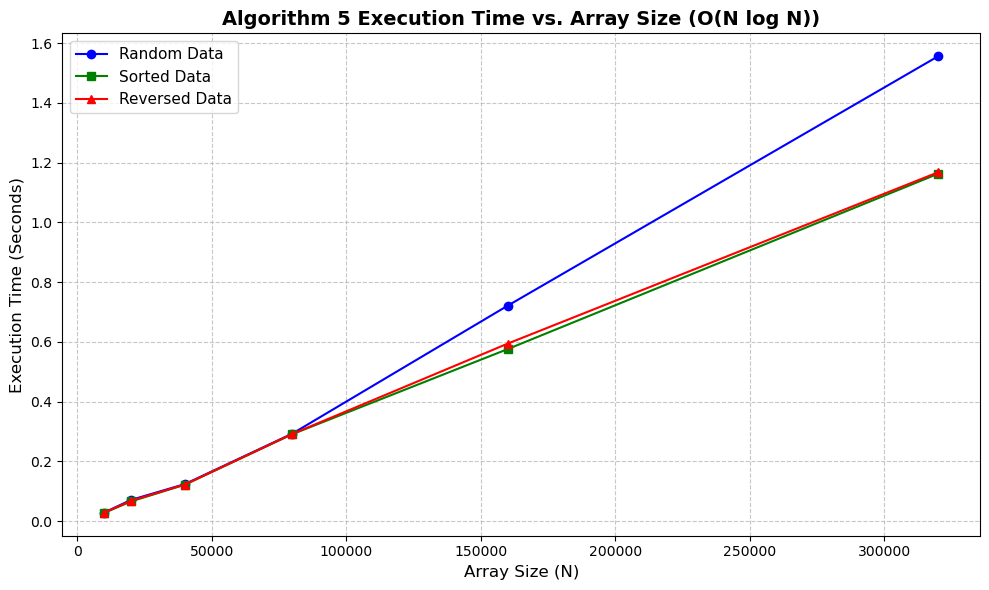

In [26]:
benchmark()

As the graph suggests, the time complexity is visually logarithmic with the input size $N$